# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [22]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('./datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [23]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f"--- {nombre}: {df.shape[0]} filas, {df.shape[1]} columnas ---")
    display(df.head(3))


--- 2018: 50 filas, 16 columnas ---


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup


--- 2022: 51 filas, 16 columnas ---


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup


--- 2026: 75 filas, 14 columnas ---


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [24]:
def perfil(df, nombre):
    print(f"=== Perfil {nombre} ===")
    print("Filas:", len(df), "| Columnas:", list(df.columns))
    print("\nValores nulos por columna:")
    print(df.isna().sum())
    print("\nDuplicados exactos (todas las columnas):", df.duplicated().sum())
    id_col = df.columns[0]
    print("Duplicados por identificador de partido:", df[id_col].duplicated().sum())
    for col in df.columns:
        if col.lower() in ('grupo', 'group_name', 'grp', 'fase', 'stage', 'round'):
            print(f"\nValores únicos en '{col}':", sorted(df[col].dropna().unique().tolist()))
    print("=" * 50, "\n")

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')


=== Perfil 2018 ===
Filas: 50 | Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Valores nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Duplicados exactos (todas las columnas): 2
Duplicados por identificador de partido: 2

Valores únicos en 'Fase': ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']

Valores únicos en 'Grupo': ['A ', 'B ', 'C ', 'D ', 'E ', 'F ', 'G ', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 'gro

## Unificar nombres de columnas

In [25]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'Año': 'mundial', 'Fase': 'fase',
        'Grupo': 'grupo', 'Jornada': 'jornada', 'Fecha': 'fecha',
        'Equipo Local': 'equipo_local', 'Equipo Visitante': 'equipo_visitante',
        'Goles Local': 'goles_local', 'Goles Visitante': 'goles_visitante',
        'Marcador': 'marcador', 'Anfitrión Local': 'local_es_anfitrion',
        'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase',
        'group_name': 'grupo', 'match_day': 'jornada', 'date': 'fecha',
        'local': 'equipo_local', 'visitor': 'equipo_visitante',
        'home_score': 'goles_local', 'away_score': 'goles_visitante',
        'score_text': 'marcador', 'home_host': 'local_es_anfitrion',
        'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id', 'wc': 'mundial', 'round': 'fase',
        'grp': 'grupo', 'md': 'jornada', 'played_on': 'fecha',
        'home': 'equipo_local', 'away': 'equipo_visitante',
        'HG': 'goles_local', 'AG': 'goles_visitante',
        'result_raw': 'marcador', 'host_h': 'local_es_anfitrion',
        'host_a': 'visitante_es_anfitrion', 'source': 'fuente',
    },
}

columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [26]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    if pd.isna(valor):
        return ''
    s = str(valor).strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('utf-8')
    s = re.sub(r'[.\-]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

catalogo['clave'] = catalogo['variante'].apply(clave_texto)
mapa_equipos = dict(zip(catalogo['clave'], catalogo['nombre_canonico']))

def nombre_canonico(valor):
    clave = clave_texto(valor)
    if clave in mapa_equipos:
        return mapa_equipos[clave]

    return str(valor).strip() if not pd.isna(valor) else np.nan

print(f"Catálogo: {len(catalogo)} variantes -> {catalogo['nombre_canonico'].nunique()} equipos únicos")

Catálogo: 95 variantes -> 58 equipos únicos


## Fechas, grupos, booleanos y marcadores

In [27]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

MESES = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,
         'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

def convertir_fecha(valor, mundial):
    if pd.isna(valor):
        return pd.NaT
    s = str(valor).strip()
    if s.lower() in ('n/d', 'n/a', 's/d', ''):
        return pd.NaT

    if re.match(r'^\d{4,6}$', s):
        origen = pd.Timestamp('1899-12-30')
        return origen + pd.Timedelta(days=int(s))

    m = re.match(r'^(\d{4})-(\d{2})-(\d{2})$', s)
    if m:
        return pd.Timestamp(int(m[1]), int(m[2]), int(m[3]))

    m = re.match(r'^([A-Za-z]{3})[a-z]*\.?\s+(\d{1,2}),?\s+(\d{4})$', s)
    if m:
        mes = MESES[m[1].lower()[:3]]
        return pd.Timestamp(int(m[3]), mes, int(m[2]))

    m = re.match(r'^(\d{1,4})[/-](\d{1,4})[/-](\d{2,4})$', s)
    if m:
        a, b, anio = int(m[1]), int(m[2]), int(m[3])
        if anio < 100:
            anio += 2000
        if a > 12 and b <= 12:
            dia, mes = a, b
        elif b > 12 and a <= 12:
            mes, dia = a, b
        else:
            dia, mes = a, b
        try:
            fecha = pd.Timestamp(anio, mes, dia)
        except ValueError:
            return pd.NaT
        return fecha

    return pd.NaT


def extraer_numero(valor):
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if s.lower() in ('n/a', 's/d', 'n/d', 'sin dato', ''):
        return np.nan
    m = re.search(r'-?\d+', s)
    return int(m.group()) if m else np.nan


MARCADOR_RE = re.compile(r'^\s*(\d+)\s*[-–—:xX]\s*(\d+)\s*$')

def separar_marcador(valor):
    if pd.isna(valor):
        return np.nan, np.nan
    m = MARCADOR_RE.match(str(valor).strip())
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan


def normalizar_grupo(valor):
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if s.lower() in ('s/d', 'n/d', 'n/a', ''):
        return np.nan
    m = re.search(r'(?<![A-Za-z])([A-La-l])(?![A-Za-z])', s)
    return m.group(1).upper() if m else np.nan


def normalizar_booleano(valor):
    if pd.isna(valor):
        return False
    s = str(valor).strip().lower()
    return s in ('sí', 'si', 'true', '1', 'verdadero')


## Función de limpieza reproducible

In [28]:
def limpiar_mundial(df, mundial):
    df = df.rename(columns=rename_maps[mundial]).copy()

    for col in columnas_base:
        if col not in df.columns:
            df[col] = False if col == 'visitante_es_anfitrion' else np.nan

    df = df[columnas_base].copy()

    df['fase'] = 'Fase de grupos'
    df['mundial'] = mundial
    df['equipo_local'] = df['equipo_local'].apply(nombre_canonico)
    df['equipo_visitante'] = df['equipo_visitante'].apply(nombre_canonico)
    df['grupo'] = df['grupo'].apply(normalizar_grupo)
    df['jornada'] = df['jornada'].apply(extraer_numero)
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)

    df['goles_local'] = df['goles_local'].apply(extraer_numero)
    df['goles_visitante'] = df['goles_visitante'].apply(extraer_numero)
    marcador_par = df['marcador'].apply(separar_marcador)
    df['marcador_gl'] = marcador_par.apply(lambda t: t[0])
    df['marcador_gv'] = marcador_par.apply(lambda t: t[1])

    hay_marcador = df['marcador_gl'].notna()
    gl_malo = df['goles_local'].isna() | (df['goles_local'] < 0) | (df['goles_local'] != df['marcador_gl'])
    gv_malo = df['goles_visitante'].isna() | (df['goles_visitante'] < 0) | (df['goles_visitante'] != df['marcador_gv'])
    usa_marcador = hay_marcador & (gl_malo | gv_malo)

    print(f"Mundial {mundial}: {usa_marcador.sum()} conflictos gol/marcador reparados con el marcador")

    df.loc[usa_marcador, 'goles_local'] = df.loc[usa_marcador, 'marcador_gl']
    df.loc[usa_marcador, 'goles_visitante'] = df.loc[usa_marcador, 'marcador_gv']
    df = df.drop(columns=['marcador_gl', 'marcador_gv'])

    equipo_a_grupo = {}
    for _, r in df.dropna(subset=['grupo']).iterrows():
        equipo_a_grupo.setdefault(r['equipo_local'], r['grupo'])
        equipo_a_grupo.setdefault(r['equipo_visitante'], r['grupo'])

    def inferir_grupo(r):
        if pd.notna(r['grupo']):
            return r['grupo']
        return equipo_a_grupo.get(r['equipo_local']) or equipo_a_grupo.get(r['equipo_visitante'])

    df['grupo'] = df.apply(inferir_grupo, axis=1)

    def inferir_fecha(r):
        if pd.notna(r['fecha']):
            return r['fecha']
        candidatos = df[(df['jornada'] == r['jornada']) & df['fecha'].notna() & df['grupo'].notna()]
        if pd.isna(r['grupo']):
            return pd.NaT
        candidatos = candidatos[candidatos['grupo'].apply(lambda g: abs(ord(g) - ord(r['grupo'])) <= 1)]
        if len(candidatos):
            return candidatos['fecha'].mode().iloc[0]
        return pd.NaT

    df['fecha'] = df.apply(inferir_fecha, axis=1)

    antes = len(df)
    df = df.drop_duplicates(subset='partido_id', keep='first').reset_index(drop=True)
    print(f"Mundial {mundial}: {antes - len(df)} duplicados eliminados, quedan {len(df)} partidos")

    df['goles_local'] = df['goles_local'].astype(int)
    df['goles_visitante'] = df['goles_visitante'].astype(int)
    df['marcador'] = df['goles_local'].astype(str) + '-' + df['goles_visitante'].astype(str)
    df['resultado_local'] = np.select(
        [df['goles_local'] > df['goles_visitante'], df['goles_local'] == df['goles_visitante']],
        ['Gana', 'Empata'], default='Pierde'
    )
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']

    return df


limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
partidos = partidos.sort_values(['mundial', 'partido_id']).reset_index(drop=True)
partidos.head()


Mundial 2018: 4 conflictos gol/marcador reparados con el marcador
Mundial 2018: 2 duplicados eliminados, quedan 48 partidos
Mundial 2022: 5 conflictos gol/marcador reparados con el marcador
Mundial 2022: 3 duplicados eliminados, quedan 48 partidos
Mundial 2026: 14 conflictos gol/marcador reparados con el marcador
Mundial 2026: 3 duplicados eliminados, quedan 72 partidos


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente,resultado_local,goles_totales,diferencia_goles
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5,0,5-0,True,False,https://github.com/jfjelstul/worldcup,Gana,5,5
1,M-2018-02,2018,Fase de grupos,A,1,2018-06-15,Egypt,Uruguay,0,1,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1,-1
2,M-2018-03,2018,Fase de grupos,B,1,2018-06-15,Morocco,Iran,0,1,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1,-1
3,M-2018-04,2018,Fase de grupos,B,1,2018-06-15,Portugal,Spain,3,3,3-3,False,False,https://github.com/jfjelstul/worldcup,Empata,6,0
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2,1,2-1,False,False,https://github.com/jfjelstul/worldcup,Gana,3,1


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [29]:
conteo = partidos['mundial'].value_counts().sort_index()
print("Partidos por mundial:\n", conteo)
assert conteo.get(2018) == 48
assert conteo.get(2022) == 48
assert conteo.get(2026) == 72
assert len(partidos) == 168

assert partidos['partido_id'].duplicated().sum() == 0, "hay partido_id duplicados"

assert (partidos['goles_local'] < 0).sum() == 0
assert (partidos['goles_visitante'] < 0).sum() == 0

campos_criticos = ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']
assert partidos[campos_criticos].isna().sum().sum() == 0, "hay nulos en campos críticos"

assert partidos['fecha'].notna().all(), "hay fechas sin resolver"
assert partidos['grupo'].isin(list('ABCDEFGHIJKL')).all(), "hay grupos fuera de A-L"

marcador_calc = partidos['goles_local'].astype(str) + '-' + partidos['goles_visitante'].astype(str)
assert (marcador_calc == partidos['marcador']).all(), "marcador inconsistente con los goles"

print("\nTodas las validaciones pasaron correctamente.")


Partidos por mundial:
 mundial
2018    48
2022    48
2026    72
Name: count, dtype: int64

Todas las validaciones pasaron correctamente.


## Comparación de los Mundiales

/tmp/ipykernel_16578/2998581443.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparacion['victorias_anfitrion'] = partidos.groupby('mundial').apply(
/tmp/ipykernel_16578/2998581443.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparacion['partidos_anfitrion'] = partidos.groupby('mundial').apply(


,mundial,partidos,goles,goles_por_partido,empates,porcentaje_empates,victorias_anfitrion,partidos_anfitrion,porcentaje_victoria_anfitrion,porcentaje_mas_2_5
0,2018,48,122,2.541667,9,0.187500,2,2,1.000000,0.500000
1,2022,48,120,2.500000,10,0.208333,0,2,0.000000,0.395833
2,2026,72,215,2.986111,20,0.277778,6,9,0.666667,0.555556


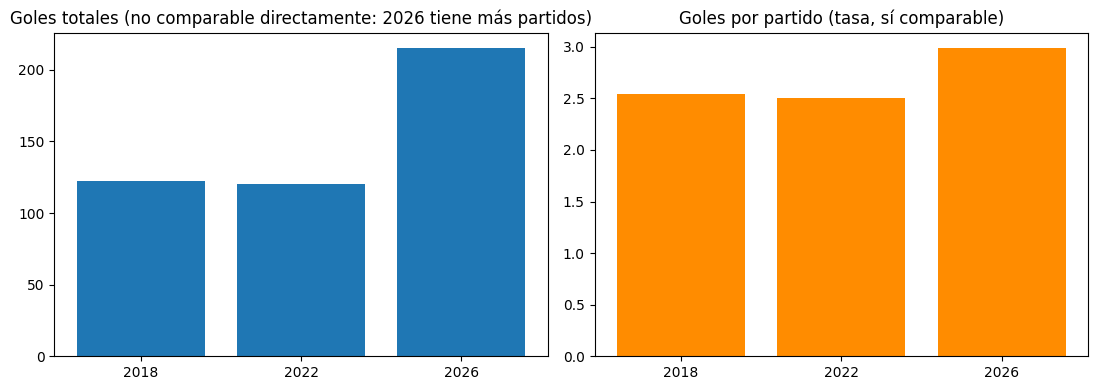

In [30]:
comparacion = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
).reset_index()
comparacion['goles_por_partido'] = comparacion['goles'] / comparacion['partidos']
comparacion['empates'] = partidos[partidos['resultado_local'] == 'Empata'].groupby('mundial')['partido_id'].count().values
comparacion['porcentaje_empates'] = comparacion['empates'] / comparacion['partidos']
comparacion['victorias_anfitrion'] = partidos.groupby('mundial').apply(
    lambda g: (((g['local_es_anfitrion']) & (g['resultado_local'] == 'Gana')) |
               ((g['visitante_es_anfitrion']) & (g['resultado_local'] == 'Pierde'))).sum()
).values
comparacion['partidos_anfitrion'] = partidos.groupby('mundial').apply(
    lambda g: (g['local_es_anfitrion'] | g['visitante_es_anfitrion']).sum()
).values
comparacion['porcentaje_victoria_anfitrion'] = comparacion['victorias_anfitrion'] / comparacion['partidos_anfitrion']
comparacion['porcentaje_mas_2_5'] = (
    partidos.groupby('mundial')['goles_totales'].apply(lambda s: (s > 2).mean()).values
)

display(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparacion['mundial'].astype(str), comparacion['goles'])
axes[0].set_title('Goles totales (no comparable directamente: 2026 tiene más partidos)')
axes[1].bar(comparacion['mundial'].astype(str), comparacion['goles_por_partido'], color='darkorange')
axes[1].set_title('Goles por partido (tasa, sí comparable)')
plt.tight_layout()
plt.show()


## Tabla por equipo

In [31]:
local = partidos[['mundial', 'equipo_local', 'goles_local', 'goles_visitante', 'resultado_local']].copy()
local.columns = ['mundial', 'equipo', 'gf', 'gc', 'resultado']

visita = partidos[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local', 'resultado_local']].copy()
visita.columns = ['mundial', 'equipo', 'gf', 'gc', 'resultado']
visita['resultado'] = visita['resultado'].map({'Gana': 'Pierde', 'Pierde': 'Gana', 'Empata': 'Empata'})

apariciones = pd.concat([local, visita], ignore_index=True)
apariciones['pts'] = apariciones['resultado'].map({'Gana': 3, 'Empata': 1, 'Pierde': 0})

tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    PJ=('resultado', 'count'),
    PG=('resultado', lambda s: (s == 'Gana').sum()),
    PE=('resultado', lambda s: (s == 'Empata').sum()),
    PP=('resultado', lambda s: (s == 'Pierde').sum()),
    GF=('gf', 'sum'),
    GC=('gc', 'sum'),
    PTS=('pts', 'sum'),
).reset_index()
tabla_equipos['DG'] = tabla_equipos['GF'] - tabla_equipos['GC']
tabla_equipos['PTS_POR_PARTIDO'] = tabla_equipos['PTS'] / tabla_equipos['PJ']
tabla_equipos = tabla_equipos.sort_values(['mundial', 'PTS', 'DG'], ascending=[True, False, False])

tabla_equipos.groupby('mundial').head(3)


,mundial,equipo,PJ,PG,PE,PP,GF,GC,PTS,DG,PTS_POR_PARTIDO
2,2018,Belgium,3,3,0,0,9,2,9,7,3.000000
6,2018,Croatia,3,3,0,0,7,1,9,6,3.000000
31,2018,Uruguay,3,3,0,0,5,0,9,5,3.000000
42,2022,England,3,2,1,0,9,2,7,7,2.333333
50,2022,Netherlands,3,2,1,0,5,1,7,4,2.333333
49,2022,Morocco,3,2,1,0,4,1,7,3,2.333333
81,2026,France,3,3,0,0,10,2,9,8,3.000000
65,2026,Argentina,3,3,0,0,8,1,9,7,3.000000
90,2026,Mexico,3,3,0,0,6,0,9,6,3.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [32]:
def construir_variables_previas(partidos):
    partidos = partidos.sort_values(['mundial', 'fecha', 'partido_id']).reset_index(drop=True)
    estado = {}

    filas = []
    for _, r in partidos.iterrows():
        m = r['mundial']
        loc, vis = r['equipo_local'], r['equipo_visitante']
        e_loc = estado.get((m, loc), {'PJ': 0, 'pts': 0, 'gf': 0, 'gc': 0})
        e_vis = estado.get((m, vis), {'PJ': 0, 'pts': 0, 'gf': 0, 'gc': 0})

        def promedio(e, campo):
            return e[campo] / e['PJ'] if e['PJ'] > 0 else 0.0

        fila = r.to_dict()
        fila['local_pts_prom_pre'] = promedio(e_loc, 'pts')
        fila['visita_pts_prom_pre'] = promedio(e_vis, 'pts')
        fila['local_gd_prom_pre'] = promedio(e_loc, 'gf') - promedio(e_loc, 'gc')
        fila['visita_gd_prom_pre'] = promedio(e_vis, 'gf') - promedio(e_vis, 'gc')
        fila['local_gf_prom_pre'] = promedio(e_loc, 'gf')
        fila['visita_gf_prom_pre'] = promedio(e_vis, 'gf')
        filas.append(fila)


        gl, gv = r['goles_local'], r['goles_visitante']
        pts_loc = 3 if gl > gv else (1 if gl == gv else 0)
        pts_vis = 3 if gv > gl else (1 if gl == gv else 0)
        e_loc = {'PJ': e_loc['PJ'] + 1, 'pts': e_loc['pts'] + pts_loc, 'gf': e_loc['gf'] + gl, 'gc': e_loc['gc'] + gv}
        e_vis = {'PJ': e_vis['PJ'] + 1, 'pts': e_vis['pts'] + pts_vis, 'gf': e_vis['gf'] + gv, 'gc': e_vis['gc'] + gl}
        estado[(m, loc)] = e_loc
        estado[(m, vis)] = e_vis

    return pd.DataFrame(filas)


features_df = construir_variables_previas(partidos)
features_df[['partido_id', 'jornada', 'local_pts_prom_pre', 'visita_pts_prom_pre']].head()


,partido_id,jornada,local_pts_prom_pre,visita_pts_prom_pre
0,M-2018-01,1,0.0,0.0
1,M-2018-02,1,0.0,0.0
2,M-2018-03,1,0.0,0.0
3,M-2018-04,1,0.0,0.0
4,M-2018-05,1,0.0,0.0


## Entrenamiento y prueba

Línea base (clase más frecuente = 'Pierde'): accuracy = 0.250
Árbol de decisión: accuracy = 0.222


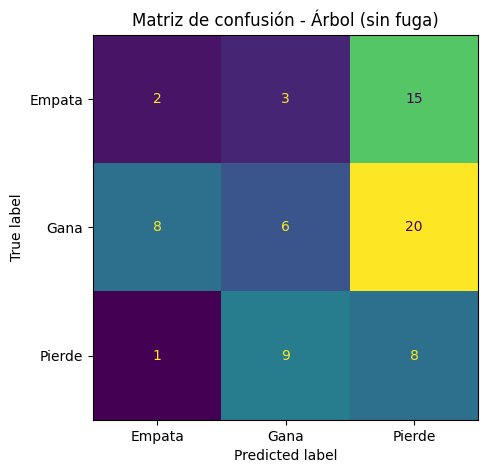

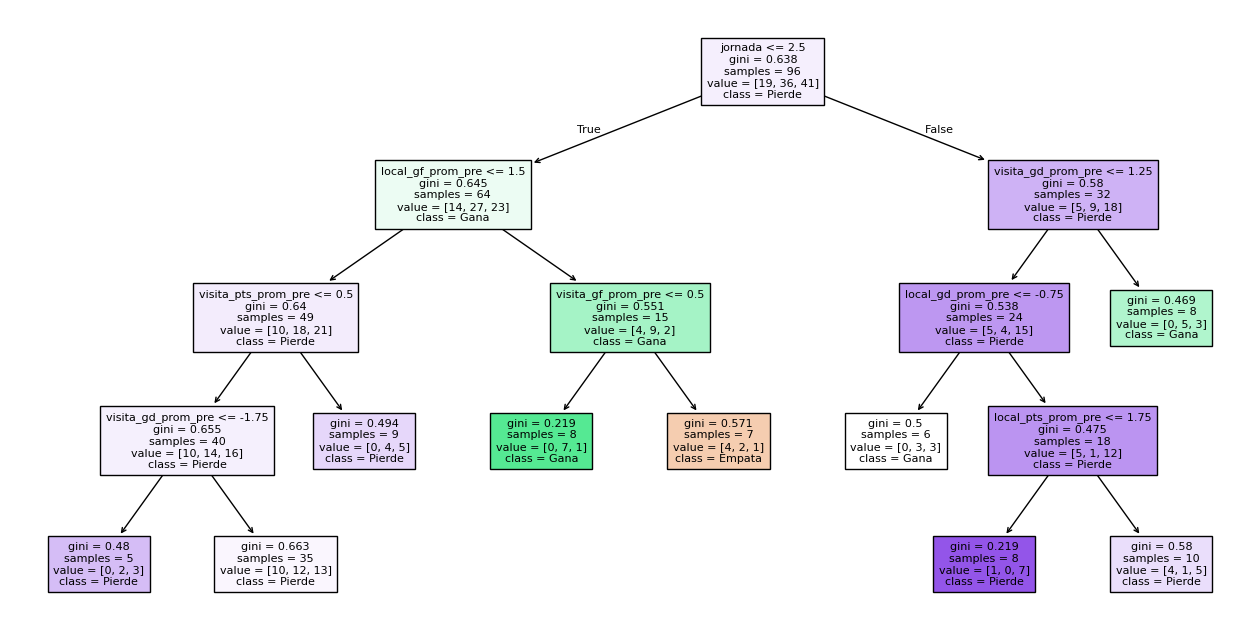

In [33]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]
objetivo = 'resultado_local'

train = features_df[features_df['mundial'].isin([2018, 2022])].copy()
test = features_df[features_df['mundial'] == 2026].copy()

X_train, y_train = train[features], train[objetivo]
X_test, y_test = test[features], test[objetivo]

linea_base = DummyClassifier(strategy='most_frequent', random_state=42)
linea_base.fit(X_train, y_train)
acc_base = accuracy_score(y_test, linea_base.predict(X_test))
print(f"Línea base (clase más frecuente = '{y_train.mode()[0]}'): accuracy = {acc_base:.3f}")

arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol.fit(X_train, y_train)
pred = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, pred)
print(f"Árbol de decisión: accuracy = {acc_arbol:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - Árbol (sin fuga)')
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(arbol, feature_names=features, class_names=arbol.classes_, filled=True, fontsize=8)
plt.show()


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [ ]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

X_train_f, y_train_f = train[features_fuga], train[objetivo]
X_test_f, y_test_f = test[features_fuga], test[objetivo]

arbol_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol_fuga.fit(X_train_f, y_train_f)
pred_fuga = arbol_fuga.predict(X_test_f)
acc_fuga = accuracy_score(y_test_f, pred_fuga)

print(f"Árbol SIN fuga:  accuracy = {acc_arbol:.3f}")
print(f"Árbol CON fuga:  accuracy = {acc_fuga:.3f}")
print("\nLa versión con fuga usa goles_local/goles_visitante/diferencia_goles, que "
      "codifican directamente el resultado del propio partido. Su precisión sube de forma "
      "artificial porque el modelo no está prediciendo el futuro: está leyendo la respuesta "
      "en las mismas variables de entrada. Un accuracy cercano a 100% en un problema de "
      "resultados deportivos es una señal de alarma, no de éxito.")


Árbol SIN fuga:  accuracy = 0.222
Árbol CON fuga:  accuracy = 1.000

La versión con fuga usa goles_local/goles_visitante/diferencia_goles, que codifican directamente el resultado del propio partido. Su precisión sube de forma artificial porque el modelo no está prediciendo el futuro: está leyendo la respuesta en las mismas variables de entrada. Un accuracy cercano a 100% en un problema de resultados deportivos es una señal de alarma, no de éxito.


## Reflexión final

Responde:

## Reflexión final

**¿Qué problema de calidad fue el más difícil?**

Lo más difícil sin duda fue lo de reparar los goles con el marcador. Al principio pensé que solo era quitar el texto "goles" o cambiar "N/A" por vacío, pero luego me di cuenta de que había casos donde el gol venía negativo (tipo -1, -2) o de plano no venía, y ahí tenía que decidir en qué confiar: ¿en el número que ya tenía la columna de goles, o en el marcador tipo "2-2"? Terminé usando la regla de que si el marcador se podía leer bien, ese mandaba. Fue tedioso porque no es un solo error, son como tres pegados (vacío, texto raro, número inválido) y tenía que revisar columna por columna cruzando información. En total salieron 22 conflictos así entre los tres mundiales.

**¿Qué decisión de limpieza podría cambiar los resultados?**

La decisión que más podría cambiar los resultados creo que es cuando inventé el grupo o la fecha de los partidos que no la traían. Lo hice viendo a qué grupo pertenecía el equipo en otro partido, o viendo qué fecha usaban los grupos "vecinos" en la misma jornada, pero al final es una suposición mía, no un dato real de la fuente. Si me equivoqué en algún caso, eso cambiaría el orden cronológico de los partidos, y como las variables para el modelo se calculan con ese orden (promedios antes de cada partido), un error ahí sí se propaga al modelo.

**¿Por qué 2026 debe compararse mediante tasas?**

Lo de comparar con tasas y no con totales es básico pero importante: 2026 tiene 72 partidos y los otros dos mundiales solo 48 porque ahora son 48 equipos en vez de 32. Si comparo goles totales, obvio 2026 va a "ganar" nada más porque hay más partidos, no porque se jueguen más ofensivo. Por eso goles por partido, % de empates, etc., son las que sí dejan comparar parejo.

**¿El árbol supera la línea base?**

El árbol no le ganó a la línea base, la verdad. La línea base (que nada más dice "Pierde" siempre porque es lo más común) dio 25% de accuracy y el árbol dio 22.2%, o sea que quedó peor. Al principio pensé que algo había hecho mal en el código, pero no, tiene sentido: solo entrené con 96 partidos y las variables son muy generales (promedios de nada más 1 o 2 partidos previos porque es fase de grupos), entonces el modelo no tiene con qué agarrar un patrón de verdad.

**¿Qué variables reales agregarías para mejorar una predicción?**

Si quisiera mejorar la predicción de verdad, agregaría cosas como el ranking FIFA de cada selección antes de empezar el torneo, el historial de enfrentamientos directos entre esos dos equipos, si tienen jugadores lesionados o suspendidos, y si ya están eliminados o clasificados (porque ahí a veces rotan a los titulares y cambia todo). Todo eso se sabe antes del partido, así que no habría fuga.

**¿Por qué un resultado de 100% puede ser una señal de alarma?**

Y por qué un 100% es sospechoso: porque en el fútbol siempre hay cosas que no puedes predecir (un rebote, una tarjeta, un error del árbitro), entonces ningún modelo debería acertar siempre. Cuando metí los goles reales como variable para probar la fuga, el accuracy se fue a 100% al toque, y ahí quedó clarísimo que no es que el modelo "aprendiera" fútbol, es que le estaba dando la respuesta disfrazada de pregunta.